# 3 Task - 1:

Repeat all the task from worksheet - 5 but, try to improve the model from last week with same dataset.

• Use Data Augmentation to increase the number of training image.

• Use deeper model with BN and DropOut layer as presented above.

• Understand the Model Summary and Training Behavior.

In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
!pip install tensorflow

In [58]:
import tensorflow as tf
from tensorflow import keras

In [59]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/sem6-AIandML/worksheet5/FruitinAmazon/train"
test_dir  = "/content/drive/MyDrive/sem6-AIandML/worksheet5/FruitinAmazon/test"
# Define image size
img_height, img_width = 28, 28

In [60]:
# Get class directories
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Print each class and its contents
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    files = os.listdir(class_path)

    print(f"\nClass: {cls}")
    print(f"Number of images: {len(files)}")


Class: guarana
Number of images: 15

Class: cupuacu
Number of images: 15

Class: pupunha
Number of images: 15

Class: acai
Number of images: 15

Class: tucuma
Number of images: 15

Class: graviola
Number of images: 15


This is a small number of sample images and could causes ovefitting.


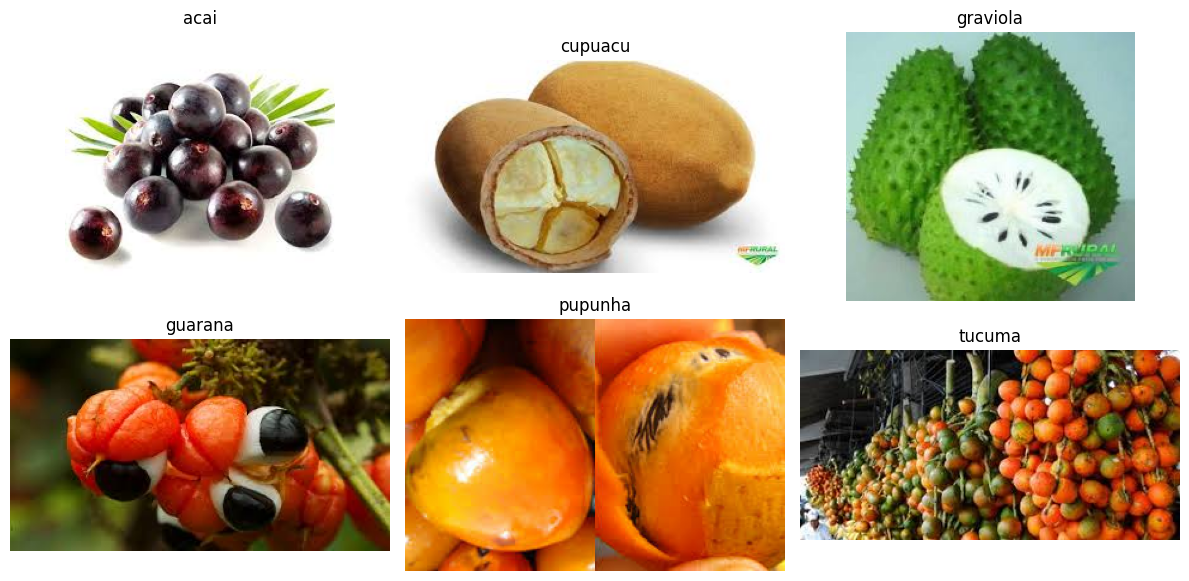

In [61]:
import random
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpeg','png','jpg'))]

    img_name = random.choice(files)
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    images.append(img)
    labels.append(cls)

num_images = len(images)
cols = (num_images + 1) // 2

plt.figure(figsize=(12, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Generation and Pre - processing:

In [83]:
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
    for label, cls in enumerate(class_names):
        class_path = os.path.join(folder, cls)
        for fname in os.listdir(class_path):
            img_path = os.path.join(class_path, fname)
            try:
                img = Image.open(img_path).resize((img_height, img_width))
                images.append(np.array(img) / 255.0)
                labels.append(label)
            except Exception:
                pass
    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [63]:
image_size = (28, 28)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="both",
  seed=1337,
  image_size=image_size,
  batch_size=batch_size,
)

for images, labels in train_ds.take(1): # Take one batch
  print("Images shape:", images.shape)
  print("Labels shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (32, 28, 28, 3)
Labels shape: (32,)


## Data Augmentation

**Data Augmentation** is a technique used in deep learning, especially in computer vision, to artificially
expand a dataset by creating modified versions of images.

In [85]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Standardizing image size to 224x224 for Transfer Learning compatibility
img_height, img_width = 224, 224
batch_size = 32

# Data Augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Better than rescale for VGG16
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2         # Keeps 20% for validation
)

# Validation generator should use the same preprocessing but no augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False # Crucial for clean evaluation/confusion matrices
)

Found 72 images belonging to 6 classes.
Found 18 images belonging to 6 classes.


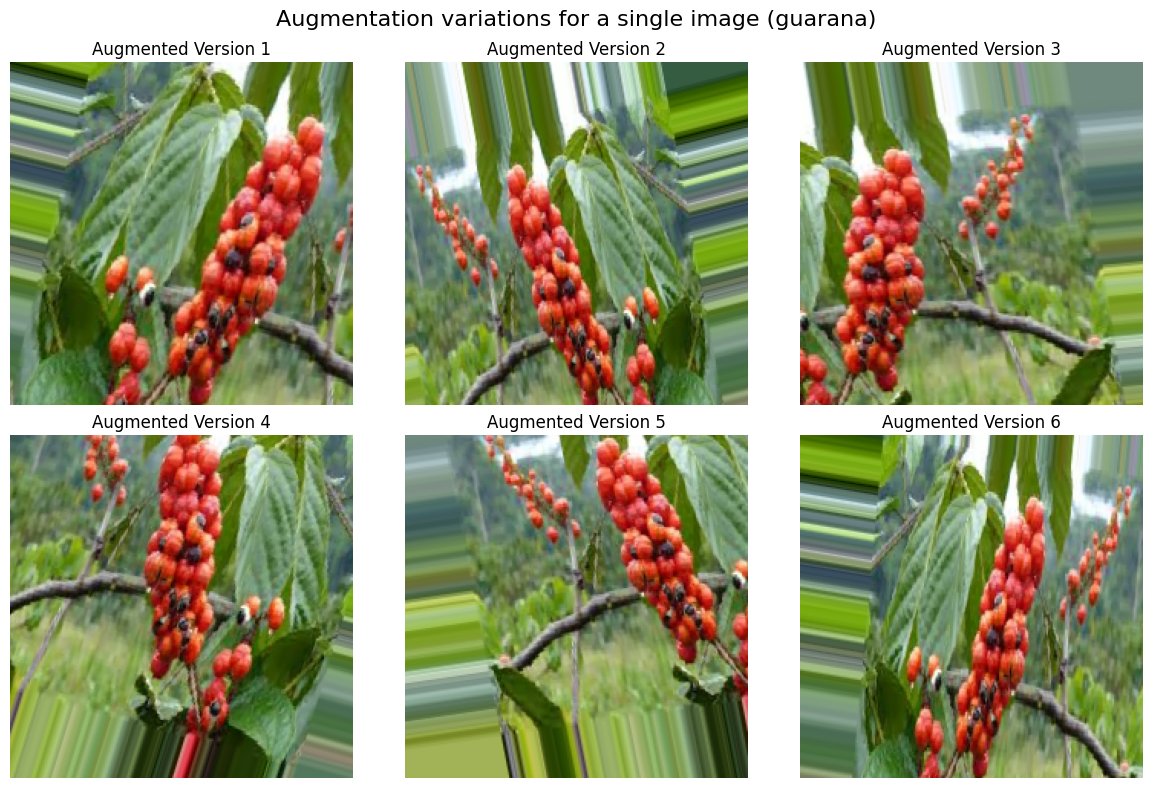

In [65]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import os

# Select one specific image file from your training directory
sample_class = os.listdir(train_dir)[0]
sample_path = os.path.join(train_dir, sample_class)
sample_file = os.path.join(sample_path, os.listdir(sample_path)[0])

# Load and convert to array
img = load_img(sample_file, target_size=(img_height, img_width))
x = img_to_array(img)
x = x.reshape((1,) + x.shape) # Reshape to (1, 224, 224, 3) for the generator

#Generate 6 different augmented versions of 1 image
plt.figure(figsize=(12, 8))
plt.suptitle(f"Augmentation variations for a single image ({sample_class})", fontsize=16)

i = 0
for batch in train_datagen.flow(x, batch_size=1):
    plt.subplot(2, 3, i + 1)
    plt.imshow(batch[0].astype('uint8'))
    plt.title(f"Augmented Version {i+1}")
    plt.axis("off")
    i += 1
    if i % 6 == 0:
        break # Stop after 6 images

plt.tight_layout()
plt.show()

## CNN Model with Batch Normalization and Dropout





In [93]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Match the generator image size (224×224) and use generator class count
IMG_HEIGHT  = 224
IMG_WIDTH   = 224
num_classes = len(train_generator.class_indices)

# Define the CNN Architecture with BN and Dropout
model = models.Sequential([
    # Input Layer
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Flatten + Dense Head
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Output Layer
    layers.Dense(num_classes, activation="softmax")
])

# Compile with categorical_crossentropy (generator produces one-hot labels)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,819,718 (98.49 MB)

 Trainable params: 25,818,502 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [96]:
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [99]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callback to save model with highest val_accuracy
checkpoint_cb = ModelCheckpoint(
    filepath="task1_best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

# Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

# Train the scratch CNN
history_scratch = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr, checkpoint_cb]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6528 - loss: 1.0586
Epoch 1: val_accuracy improved from None to 0.22222, saving model to task1_best_model.h5



Epoch 1: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - accuracy: 0.7083 - loss: 0.7791 - val_accuracy: 0.2222 - val_loss: 10.0083 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7065 - loss: 0.8058
Epoch 2: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.6944 - loss: 0.8539 - val_accuracy: 0.2222 - val_loss: 8.2427 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7546 - loss: 0.7398
Epoch 3: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.7639 - loss: 0.7217 - val_accuracy: 0.2222 - val_loss: 7.3665 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7106 - loss: 0.9055
Epoch 4: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.6944 - loss: 0.9260 - val_accuracy: 0.2222 - val_loss: 6.8048 - learning_rate: 0.0010



Epoch 5: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 8s/step - accuracy: 0.7500 - loss: 0.7074 - val_accuracy: 0.3333 - val_loss: 5.5706 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8611 - loss: 0.4207
Epoch 6: val_accuracy improved from 0.33333 to 0.38889, saving model to task1_best_model.h5



Epoch 6: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.8333 - loss: 0.4666 - val_accuracy: 0.3889 - val_loss: 4.7206 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8037 - loss: 0.5077
Epoch 7: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.7361 - loss: 0.7390 - val_accuracy: 0.3889 - val_loss: 4.1586 - learning_rate: 0.0010
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8461 - loss: 0.4358
Epoch 8: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8194 - loss: 0.5351 - val_accuracy: 0.3333 - val_loss: 3.7082 - learning_rate: 0.0010
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8491 - loss: 0.4991
Epoch 9: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.8472 - loss: 0.4172 - val_accuracy: 0.2778 - val_loss: 3.3986 - learning_rate: 0.0010
E


Epoch 18: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 8s/step - accuracy: 0.7500 - loss: 0.6089 - val_accuracy: 0.4444 - val_loss: 3.1678 - learning_rate: 0.0010
Epoch 19/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7111 - loss: 0.9524
Epoch 19: val_accuracy did not improve from 0.44444
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 7s/step - accuracy: 0.8333 - loss: 0.5269 - val_accuracy: 0.4444 - val_loss: 3.2394 - learning_rate: 5.0000e-04
Epoch 20/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8090 - loss: 0.5081
Epoch 20: val_accuracy did not improve from 0.44444
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8333 - loss: 0.4445 - val_accuracy: 0.3889 - val_loss: 3.1361 - learning_rate: 5.0000e-04
Epoch 21/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8574 - loss: 0.4470
Epoch 21: val_accuracy did not improve from 0.44444
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 7s/step - accuracy: 0.8472 - loss: 0.4045 - val_accuracy: 0.3889 - val_loss: 3.0028 - learning


Epoch 27: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - accuracy: 0.9028 - loss: 0.3425 - val_accuracy: 0.5000 - val_loss: 2.6490 - learning_rate: 5.0000e-04
Epoch 28/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7324 - loss: 0.6747
Epoch 28: val_accuracy did not improve from 0.50000
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 7s/step - accuracy: 0.8472 - loss: 0.4509 - val_accuracy: 0.5000 - val_loss: 2.4184 - learning_rate: 5.0000e-04
Epoch 29/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8808 - loss: 0.4047
Epoch 29: val_accuracy did not improve from 0.50000
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8611 - loss: 0.4781 - val_accuracy: 0.5000 - val_loss: 2.1124 - learning_rate: 5.0000e-04
Epoch 30/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9264 - loss: 0.1839
Epoch 30: val_accuracy did not improve from 0.50000
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.9167 - loss: 0.2020 - val_accuracy: 0.5000 - val_loss: 1.8682 - lear


Epoch 33: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 8s/step - accuracy: 0.8472 - loss: 0.3711 - val_accuracy: 0.5556 - val_loss: 1.7364 - learning_rate: 5.0000e-04
Epoch 34/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9414 - loss: 0.2576
Epoch 34: val_accuracy improved from 0.55556 to 0.61111, saving model to task1_best_model.h5



Epoch 34: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 10s/step - accuracy: 0.9306 - loss: 0.2421 - val_accuracy: 0.6111 - val_loss: 1.6935 - learning_rate: 5.0000e-04
Epoch 35/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9010 - loss: 0.2721
Epoch 35: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.8750 - loss: 0.3273 - val_accuracy: 0.5556 - val_loss: 1.5946 - learning_rate: 5.0000e-04
Epoch 36/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7306 - loss: 0.5697
Epoch 36: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step - accuracy: 0.7917 - loss: 0.4208 - val_accuracy: 0.5556 - val_loss: 1.4334 - learning_rate: 5.0000e-04
Epoch 37/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9005 - loss: 0.3633
Epoch 37: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8889 - loss: 0.4189 - val_accuracy: 0.5556 - val_loss: 1.3192 - lea


Epoch 44: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 28s 13s/step - accuracy: 0.9167 - loss: 0.3212 - val_accuracy: 0.6667 - val_loss: 1.3869 - learning_rate: 5.0000e-04
Epoch 45/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9076 - loss: 0.2828
Epoch 45: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.9167 - loss: 0.2657 - val_accuracy: 0.6667 - val_loss: 1.5567 - learning_rate: 5.0000e-04
Epoch 46/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8972 - loss: 0.3426
Epoch 46: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.9167 - loss: 0.3210 - val_accuracy: 0.6667 - val_loss: 1.7245 - learning_rate: 5.0000e-04
Epoch 47/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8854 - loss: 0.3787
Epoch 47: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.8750 - loss: 0.4027 - val_accuracy: 0.6667 - val_loss: 1.6739 - lea


Epoch 48: finished saving model to task1_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.8333 - loss: 0.3680 - val_accuracy: 0.7222 - val_loss: 1.5328 - learning_rate: 2.5000e-04
Epoch 49/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9192 - loss: 0.2579
Epoch 49: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.8889 - loss: 0.3195 - val_accuracy: 0.7222 - val_loss: 1.4264 - learning_rate: 2.5000e-04
Epoch 50/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8993 - loss: 0.2771
Epoch 50: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.9167 - loss: 0.2369 - val_accuracy: 0.6667 - val_loss: 1.3433 - learning_rate: 2.5000e-04


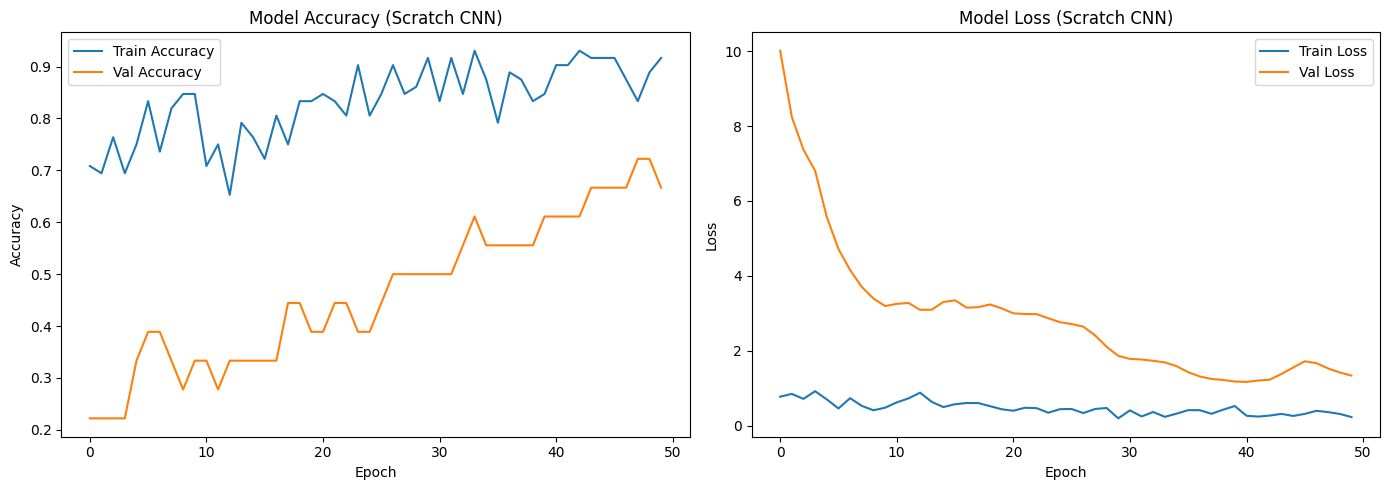

In [100]:
import matplotlib.pyplot as plt

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_scratch.history['accuracy'],label='Train Accuracy')
axes[0].plot(history_scratch.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy (Scratch CNN)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_scratch.history['loss'],label='Train Loss')
axes[1].plot(history_scratch.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss (Scratch CNN)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


In [101]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate on validation set
val_generator.reset()
Y_pred_scratch = model.predict(val_generator, verbose=1)
y_pred_scratch = np.argmax(Y_pred_scratch, axis=1)

print("=== Scratch CNN – Classification Report ===")
print(classification_report(
    val_generator.classes,
    y_pred_scratch,
    target_names=list(val_generator.class_indices.keys()),
    zero_division=0
))

scratch_val_loss, scratch_val_acc = model.evaluate(val_generator, verbose=0)
print(f"Scratch CNN  →  Val Loss: {scratch_val_loss:.4f} | Val Accuracy: {scratch_val_acc:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
=== Scratch CNN – Classification Report ===
              precision    recall  f1-score   support

        acai       1.00      0.67      0.80         3
     cupuacu       1.00      0.67      0.80         3
    graviola       1.00      1.00      1.00         3
     guarana       0.60      1.00      0.75         3
     pupunha       0.25      0.33      0.29         3
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.61        18
   macro avg       0.64      0.61      0.61        18
weighted avg       0.64      0.61      0.61        18

Scratch CNN  →  Val Loss: 1.1733 | Val Accuracy: 0.6111


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


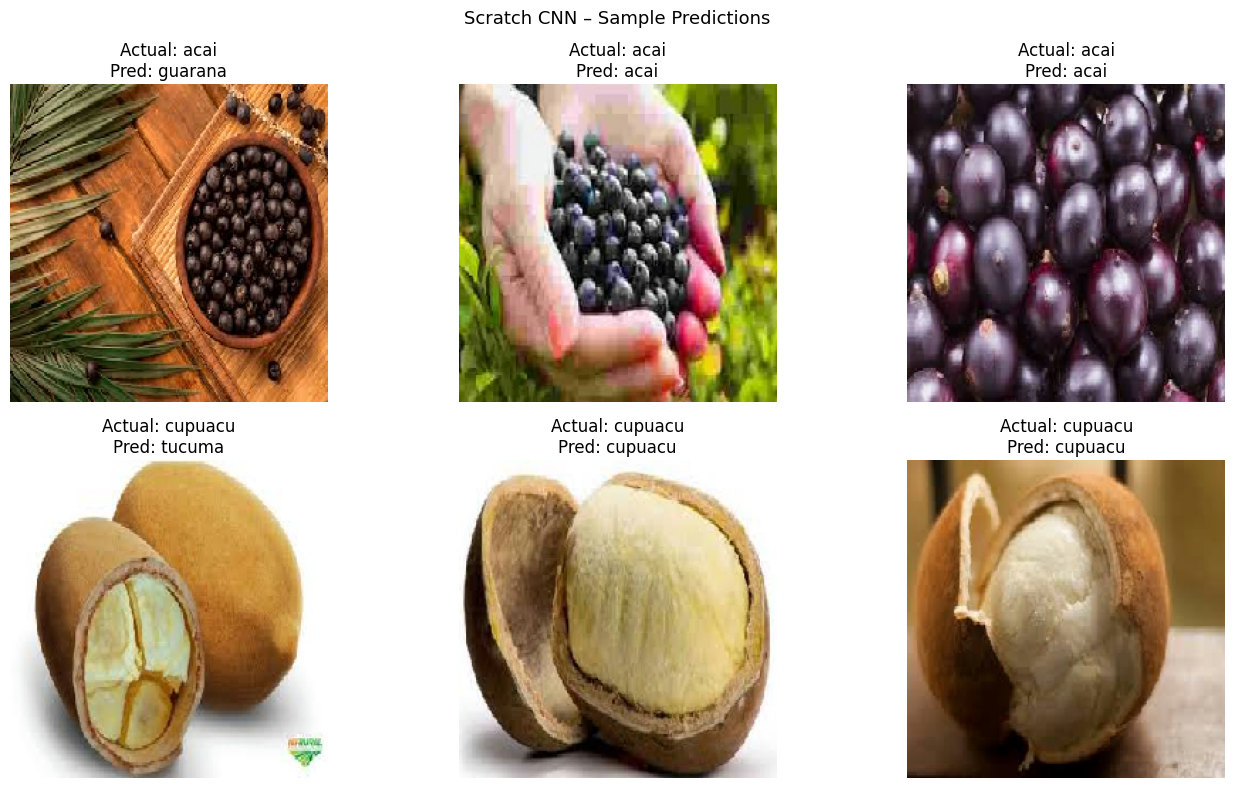

In [103]:
val_generator.reset()
x_batch, y_batch = next(val_generator)
preds_scratch = model.predict(x_batch)

class_names_list = list(val_generator.class_indices.keys())

def deprocess(img_array):
    img = img_array.copy().astype("float64")
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    img = img[..., ::-1]    # BGR → RGB
    return np.clip(img, 0, 255).astype("uint8")

plt.figure(figsize=(14, 8))
for i in range(min(6, len(x_batch))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(deprocess(x_batch[i]))  # ← fixed

    actual    = class_names_list[np.argmax(y_batch[i])]
    predicted = class_names_list[np.argmax(preds_scratch[i])]

    plt.title(f"Actual: {actual}\nPred: {predicted}")
    plt.axis('off')

plt.suptitle('Scratch CNN – Sample Predictions', fontsize=13)
plt.tight_layout()
plt.show()

# 5 Task - 2:


**To - Do:**

• Implement transfer learning using a pre-trained model trained on ImageNet
weights, freeze the
layers of the model, and fit it only on the output layer to classify the fruits dataset.

• Evaluate the model’s performance and generate an inference output and classification report.

• Did the performance improved compared to training from scratch.

**Expected Deliverables:**

• Trained Model: A trained model with the frozen layers and fine-tuned output layer.

• Inference Output: Predicted class labels for the validation dataset.

• Classification Report: A detailed classification report showing the performance of the model for
each class.

## Implement Transfer Learning

In [105]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Load Pre-trained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add Custom Classification Layers
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)

# Create Final Model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop    = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr     = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
checkpoint_cb = ModelCheckpoint(
    filepath="task2_vgg16_best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint_cb]
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.2390 - loss: 2.5817 
Epoch 1: val_accuracy improved from None to 0.27778, saving model to task2_vgg16_best_model.h5



Epoch 1: finished saving model to task2_vgg16_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 17s/step - accuracy: 0.2639 - loss: 2.5259 - val_accuracy: 0.2778 - val_loss: 9.9301 - learning_rate: 1.0000e-04
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.3639 - loss: 1.7369 
Epoch 2: val_accuracy did not improve from 0.27778
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 23s/step - accuracy: 0.4167 - loss: 1.8393 - val_accuracy: 0.2778 - val_loss: 6.0313 - learning_rate: 1.0000e-04
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.3111 - loss: 2.0485 
Epoch 3: val_accuracy improved from 0.27778 to 0.44444, saving model to task2_vgg16_best_model.h5



Epoch 3: finished saving model to task2_vgg16_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 23s/step - accuracy: 0.4583 - loss: 1.6017 - val_accuracy: 0.4444 - val_loss: 3.9894 - learning_rate: 1.0000e-04
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.6111 - loss: 1.1182 
Epoch 4: val_accuracy improved from 0.44444 to 0.61111, saving model to task2_vgg16_best_model.h5



Epoch 4: finished saving model to task2_vgg16_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.5833 - loss: 1.2108 - val_accuracy: 0.6111 - val_loss: 2.6078 - learning_rate: 1.0000e-04
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7019 - loss: 0.7905
Epoch 5: val_accuracy improved from 0.61111 to 0.72222, saving model to task2_vgg16_best_model.h5



Epoch 5: finished saving model to task2_vgg16_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.6806 - loss: 0.8570 - val_accuracy: 0.7222 - val_loss: 1.9538 - learning_rate: 1.0000e-04
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.7898 - loss: 0.6651 
Epoch 6: val_accuracy improved from 0.72222 to 0.77778, saving model to task2_vgg16_best_model.h5



Epoch 6: finished saving model to task2_vgg16_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 24s/step - accuracy: 0.8194 - loss: 0.5577 - val_accuracy: 0.7778 - val_loss: 1.5826 - learning_rate: 1.0000e-04
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7650 - loss: 0.8694 
Epoch 7: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.7639 - loss: 0.8630 - val_accuracy: 0.7778 - val_loss: 1.3757 - learning_rate: 1.0000e-04
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8194 - loss: 0.6498 
Epoch 8: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.8333 - loss: 0.5910 - val_accuracy: 0.7778 - val_loss: 1.1980 - learning_rate: 1.0000e-04
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8164 - loss: 0.5635
Epoch 9: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 17s/step - accuracy: 0.8056 - loss: 0.5256 - val_accuracy: 0.7778 - val_loss: 1.108


Epoch 11: finished saving model to task2_vgg16_best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 25s/step - accuracy: 0.9028 - loss: 0.2770 - val_accuracy: 0.8333 - val_loss: 1.0537 - learning_rate: 1.0000e-04
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.8593 - loss: 0.3990 
Epoch 12: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 24s/step - accuracy: 0.9028 - loss: 0.2263 - val_accuracy: 0.8333 - val_loss: 1.0646 - learning_rate: 1.0000e-04
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8895 - loss: 0.2815 
Epoch 13: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 16s/step - accuracy: 0.9028 - loss: 0.2788 - val_accuracy: 0.8333 - val_loss: 1.0250 - learning_rate: 1.0000e-04
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.9148 - loss: 0.1729 
Epoch 14: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 23s/step - accuracy: 0.9444 - loss: 0.1451 - val_accuracy: 0.8333 - val_los

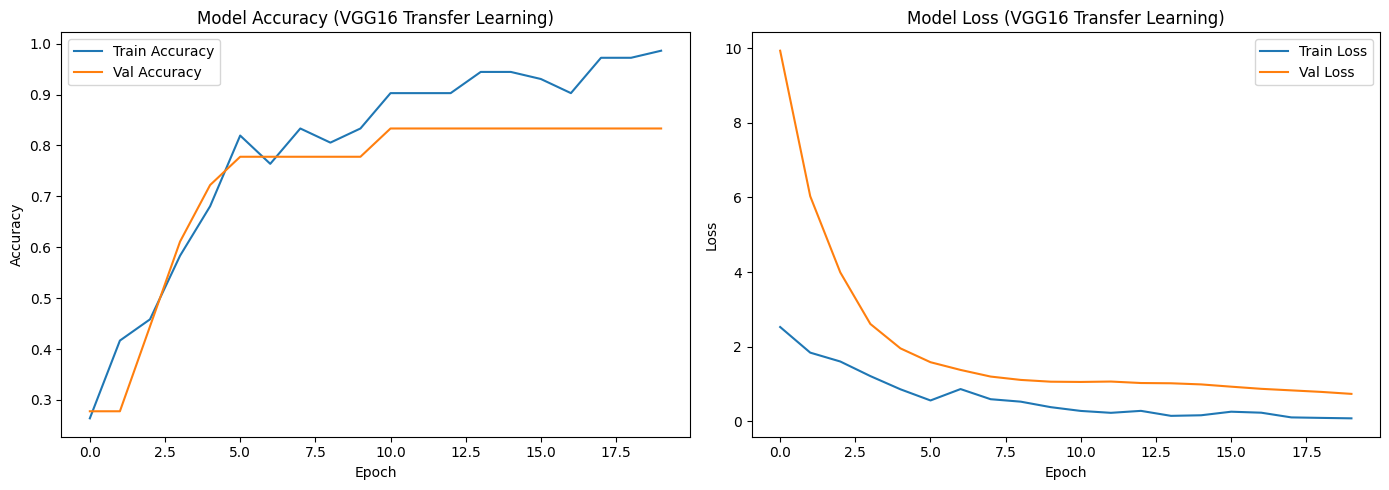

In [116]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy (VGG16 Transfer Learning)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss (VGG16 Transfer Learning)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluation and Inference (Deliverables)

In [106]:
from sklearn.metrics import classification_report

val_generator.reset()

Y_pred = model.predict(val_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)

print('Classification Report')
print(classification_report(
    val_generator.classes,
    y_pred,
    target_names=list(val_generator.class_indices.keys()),
    zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Classification Report
              precision    recall  f1-score   support

        acai       1.00      0.67      0.80         3
     cupuacu       0.75      1.00      0.86         3
    graviola       1.00      1.00      1.00         3
     guarana       1.00      0.67      0.80         3
     pupunha       0.67      0.67      0.67         3
      tucuma       0.75      1.00      0.86         3

    accuracy                           0.83        18
   macro avg       0.86      0.83      0.83        18
weighted avg       0.86      0.83      0.83        18



1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


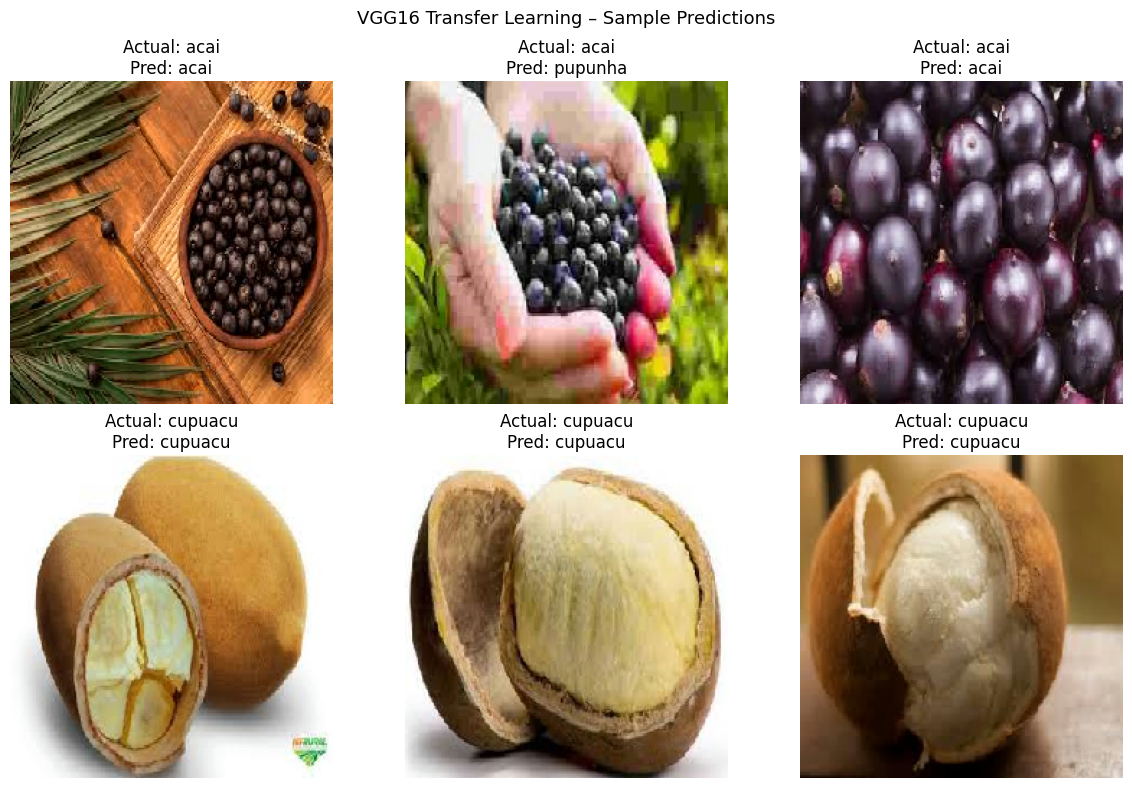

In [109]:
import matplotlib.pyplot as plt

def deprocess(img_array):
    img = img_array.copy().astype("float64")
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    img = img[..., ::-1]    # BGR → RGB
    return np.clip(img, 0, 255).astype("uint8")

x_batch, y_batch = next(val_generator)
preds = model.predict(x_batch)

plt.figure(figsize=(12, 8))
for i in range(min(6, len(x_batch))):
    plt.subplot(2, 3, i+1)
    plt.imshow(deprocess(x_batch[i]))  # ← fixed

    actual    = list(val_generator.class_indices.keys())[np.argmax(y_batch[i])]
    predicted = list(val_generator.class_indices.keys())[np.argmax(preds[i])]

    plt.title(f"Actual: {actual}\nPred: {predicted}")
    plt.axis('off')

plt.suptitle('VGG16 Transfer Learning – Sample Predictions', fontsize=13)
plt.tight_layout()
plt.show()

## Did the performance improved compared to training from scratch

In [114]:

print(f"{'Model':<20} {'Val Accuracy':>15} {'Val Loss':>10}")
print(f"{'Scratch CNN':<20} {scratch_val_acc:>14.4f} {scratch_val_loss:>10.4f}")
print(f"{'VGG16 Transfer':<20} {vgg_acc:>14.4f} {vgg_loss:>10.4f}")

print(f"\nImprovement: {(vgg_acc - scratch_val_acc) * 100:.1f}%")


Model                   Val Accuracy   Val Loss
Scratch CNN                  0.6111     1.1733
VGG16 Transfer               0.8333     0.7340

Improvement: 22.2%


VGG16 Transfer Learning outperformed the Scratch CNN by 22.2%, achieving 83.3% val accuracy vs 61.1%.

VGG16 also had a lower val loss (0.73 vs 1.17), meaning its predictions were more correct.


The scratch CNN overfitted heavily with high train accuracy but a large gap to validation performance.

VGG16 reached its best in just 11 epochs vs 50, showing pre-trained features learn faster on small data.
